# Fine-Tuning LLMs — Short Notes

## 1. What is Fine-Tuning?

- [LoRA fine-tuning Hyperparameters Guide](https://unsloth.ai/docs/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide)
A pretrained LLM learns general language patterns and knowledge from massive amounts of raw text.

**Fine-tuning** takes an already pretrained model and trains it further on a smaller, task-specific or instruction-specific dataset.

### LLM Training Pipeline

Raw Text → Pretraining → Base Model → SFT → Instruction-Tuned Model → Preference Alignment

- **Pretraining:** learns language, patterns, facts and general capabilities.
- **Supervised Fine-Tuning (SFT):** teaches the model how to follow instructions and produce desired responses.
- **Preference Alignment:** further aligns responses with human preferences using techniques such as RLHF/DPO.

> Important: Pretraining and SFT both fundamentally use **next-token prediction**.

---

# 2. Supervised Fine-Tuning (SFT)

SFT trains a pretrained model using examples of desired input-output behavior.

Example:

User:
"Explain gravity simply."

Assistant:
"Gravity is the force that pulls objects toward each other..."

The model learns:

**Instruction → Appropriate Response**

A key idea from the lecture:

> SFT primarily teaches the model how to respond and behave, rather than being the main stage where broad world knowledge is acquired.

---

# 3. Next-Token Prediction

Both pretraining and SFT use next-token prediction.

Example:

Input:

The → sky → is → very → blue

Labels are shifted by one token:

| Input | Target |
|---|---|
| The | sky |
| sky | is |
| is | very |
| very | blue |
| blue | `<eos>` |

The model predicts a probability distribution over the vocabulary at every position.

### Loss Function

$$
\mathcal{L}(\theta)
=
-\sum_{t=1}^{T-1}
\log P_\theta(x_{t+1}|x_{\le t})
$$

This is the **negative log-likelihood / cross-entropy loss**.

For one token:

$$
Loss = -\log(p_y)
$$

where $p_y$ is the probability assigned to the correct token.

Higher probability for the correct token → lower loss.

---

# 4. What Makes SFT Different from Pretraining?

The fundamental objective is still next-token prediction.

The important difference is **loss masking**.

Suppose the training sequence contains:

[USER PROMPT] + [ASSISTANT RESPONSE]

During SFT:

- Prompt tokens provide context.
- Response tokens are the desired output.
- Loss can be calculated only on the assistant/response tokens.

Conceptually:

Prompt Tokens → Loss Masked  
Response Tokens → Loss Calculated

This teaches the model how to **answer instructions**, rather than learning to reproduce the instruction itself.

---

# 5. SFT Dataset Formats

## Alpaca Format

```json
{
    "instruction": "Write a haiku about machine learning.",
    "input": "",
    "output": "Data flows like streams..."
}


---

### Conversational / Chat Format

Modern chat models generally use role-based conversations.

```json
{
    "messages": [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Explain gravity simply."},
        {"role": "assistant", "content": "Gravity is..."}
    ]
}
```

- Modern chat models generally use **role-based conversations**.
- Each model family can have its own **chat template** and **special tokens**.

---

### Prompt-Completion Format

```json
{
    "prompt": "Translate to French: Hello world",
    "completion": "Bonjour le monde"
}
```

- Loss is applied only to the **completion tokens**.

---

# 6. Full Fine-Tuning

In **full fine-tuning**, every parameter of the model is trainable.

If

$$
W_0 = \text{pretrained weights}
$$

then training directly modifies

$$
W_0
$$

## Problem

LLMs contain **billions of parameters**.

For a **7B model**, full fine-tuning can require roughly **~70 GB minimum memory** (mixed precision + AdamW example from the lecture).

Memory is required for:

- Model weights
- Gradients
- Optimizer states

Therefore, full fine-tuning large LLMs is expensive.

This motivates:

> **PEFT — Parameter-Efficient Fine-Tuning**

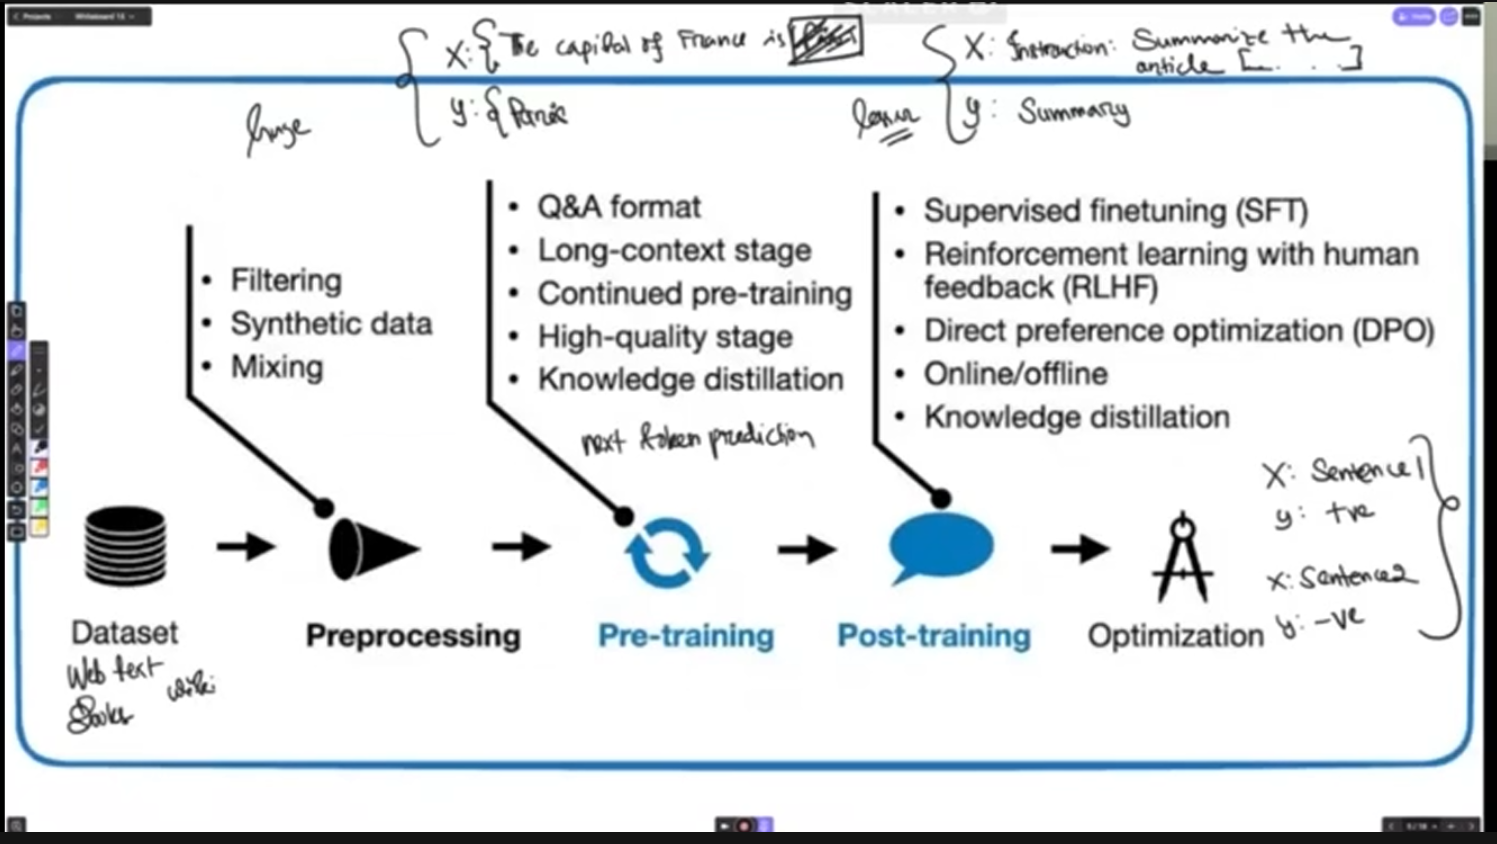

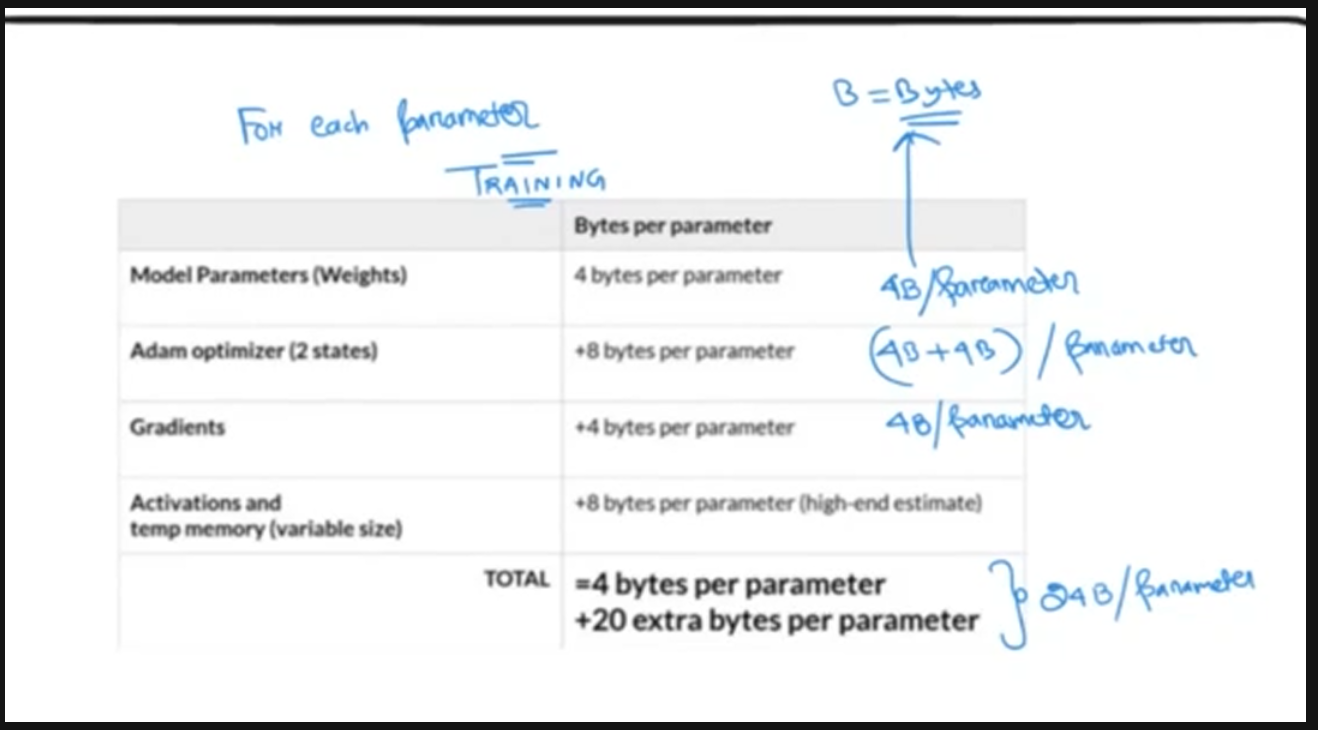

---

# 7. Parameter-Efficient Fine-Tuning (PEFT)

PEFT freezes most or all pretrained parameters and trains only a small number of additional parameters.

## Benefits

- Much lower GPU memory requirement
- Faster/cheaper training
- Small task-specific adapters
- One base model can support many tasks

## Important PEFT Techniques

- Adapter Layers
- Prefix Tuning
- LoRA

LoRA is one of the most widely used approaches.

---

# 8. LoRA — Low-Rank Adaptation

Instead of modifying the entire pretrained weight matrix,

$$
W' = W_0 + \Delta W
$$

LoRA represents the update using two much smaller matrices:

$$
\Delta W = BA
$$

Therefore,

$$
W' = W_0 + \frac{\alpha}{r}BA
$$

where

- $W_0$ = frozen pretrained weights
- $A$ = trainable down-projection matrix
- $B$ = trainable up-projection matrix
- $r$ = LoRA rank
- $\alpha$ = scaling parameter

Usually,

$$
r \ll d
$$

so the number of trainable parameters becomes dramatically smaller.

---

# 9. LoRA Forward Pass

Instead of

$$
h = W_0x
$$

LoRA computes

$$
h = W_0x + \frac{\alpha}{r}BAx
$$

Think of this as two branches:

```text
Input x
│
├── Frozen Model Weights W₀ ──→ W₀x
│
└── LoRA A → B ───────────────→ BAx
│
scaled by α/r
│
Add both outputs
↓
Output h
```

Only **A** and **B** are trained.

$W_0$ remains frozen.

---



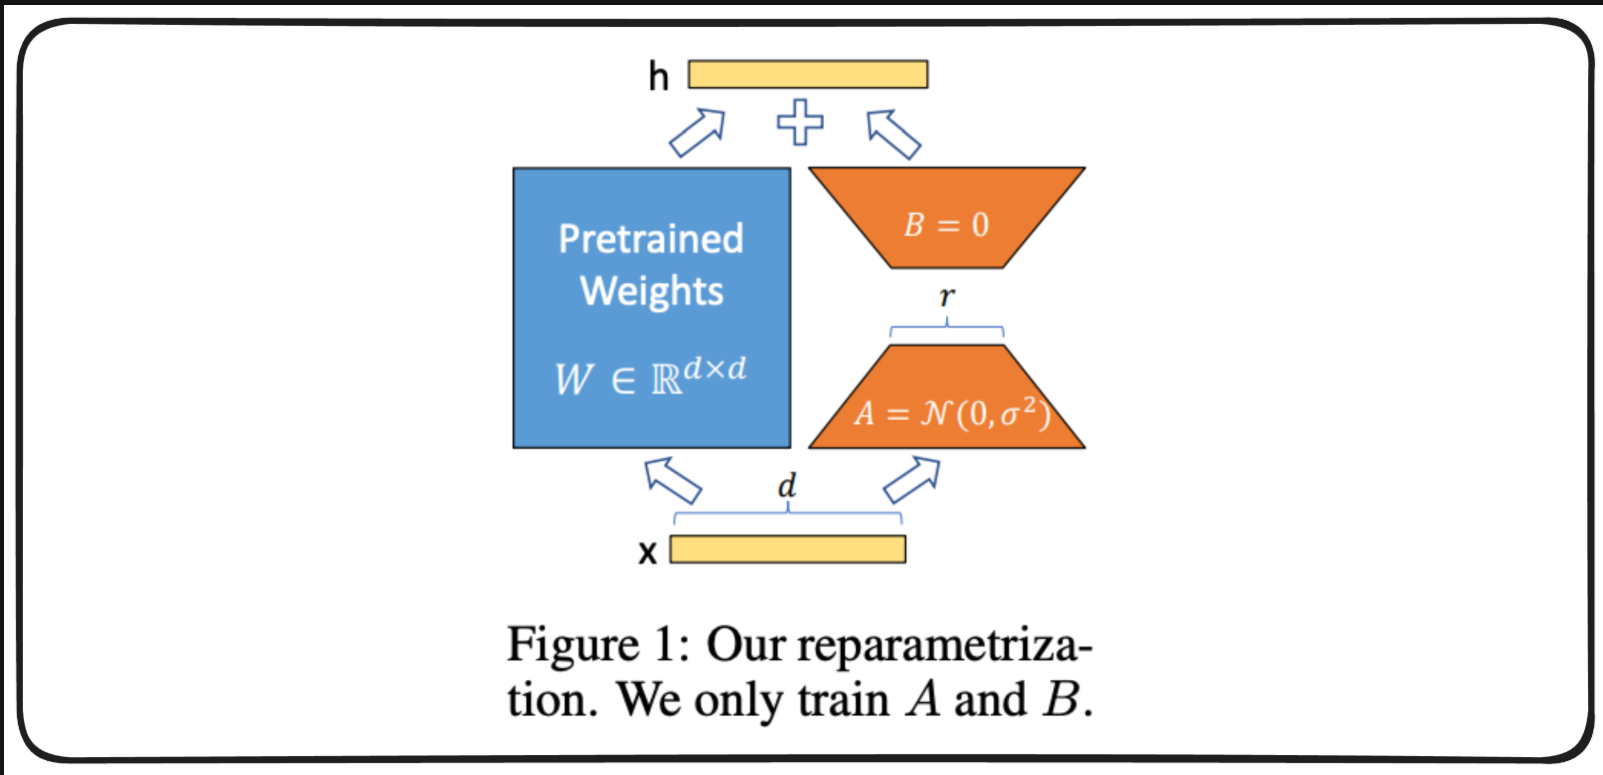

- Frozen $W_0$ branch
- Trainable $A/B$ branch

---

# 10. Why LoRA Saves Parameters

Suppose

$$
W \in \mathbb{R}^{d \times k}
$$

Full fine-tuning trains

$$
d \times k
$$

parameters.

LoRA trains

$$
r(d+k)
$$

parameters.

### Example

$$
d = k = 4096
$$

Full Fine-Tuning

$$
4096 \times 4096 = 16,777,216
$$

parameters.

LoRA with

$$
r = 8
$$

trains

$$
8(4096+4096)=65,536
$$

parameters.

That's approximately a **99.6% reduction**.

---

# 11. LoRA Initialization

Initially,

- Matrix **A** → small random initialization
- Matrix **B** → initialized to zeros

Therefore

$$
BA=0
$$

and

$$
W' = W_0
$$

The model initially behaves exactly like the pretrained model.

---

# 12. Why Does Low Rank Work?

Large neural networks contain significant redundancy.

This relates to the **Intrinsic Dimension Hypothesis**:

Useful model adaptation often occurs in a much lower-dimensional space than the total parameter space.

LoRA assumes

$$
\text{rank}(\Delta W) \ll \text{rank}(W)
$$

Meaning the adaptation can often be represented using a low-rank update.

---

# 13. Where is LoRA Applied?

Transformer blocks contain large linear projection matrices.

## Attention

- q_proj
- k_proj
- v_proj
- o_proj

## Feed-Forward Network (MLP)

- gate_proj
- up_proj
- down_proj

Original LoRA commonly targeted:

```python
["q_proj", "v_proj"]
```

Modern recommendation:

```python
[
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj"
]
```

---

# 14. Important LoRA Hyperparameters

## Rank (r)

Controls the capacity of the LoRA adapter.

Typical values:

```text
4
8
16
32
64
```

Good starting point:

```text
r = 16
```

Higher rank:

- More trainable parameters
- More expressive
- More memory

Lower rank:

- Fewer parameters
- Faster
- Less expressive

---

## Alpha (lora_alpha)

Controls the magnitude of the LoRA update.

Scaling:

$$
\frac{\alpha}{r}
$$

Rule of thumb:

$$
\alpha \approx 1\text{–}2 \times r
$$

Example:

```text
r = 16
lora_alpha = 32
```

Then

$$
\frac{\alpha}{r}=2
$$

---

## LoRA Dropout

Regularizes the LoRA branch.

Typical values:

```text
0.0   → Faster
0.05  → Common default
0.10  → Stronger regularization
```

---

## Learning Rate

Lecture recommendations:

LoRA SFT

```text
learning_rate = 2e-4
```

Full Fine-Tuning

```text
learning_rate ≈ 2e-5
```

LoRA commonly uses a higher learning rate.

---

# 15. Full Fine-Tuning vs LoRA

| Feature | Full Fine-Tuning | LoRA |
|----------|------------------|------|
| Base weights | Updated | Frozen |
| Trainable params | Nearly 100% | Small fraction |
| Memory | Very high | Much lower |
| Training cost | High | Lower |
| Task adapters | Entire model | Small adapters |
| Consumer GPU | Difficult | Practical |
| Deployment | Separate models | Base + adapters |

---

# 16. LoRA Adapter Merging

After training,

$$
W' = W_0 + \frac{\alpha}{r}BA
$$

The LoRA update can be merged into the original model weights.

Advantages:

- Normal architecture during inference
- No extra LoRA computation
- Zero additional inference latency

---

# 17. SFT + LoRA Workflow

```text
Base LLM
    ↓
Load Tokenizer
    ↓
Prepare Instruction Dataset
    ↓
Apply Chat Template
    ↓
Configure LoRA
    ↓
Freeze Base Weights
    ↓
Train LoRA Parameters with SFT
    ↓
Save Adapter
    ↓
Attach / Merge Adapter
    ↓
Fine-Tuned Model
```

Lecture implementation stack:

- Hugging Face Transformers
- datasets
- trl
- peft
- accelerate
- PyTorch
- TensorBoard

Example base model:

```text
Qwen/Qwen2.5-1.5B
```

Example dataset:

```text
Alpaca (~52K examples)
```

---

# 18. SFTTrainer

TRL provides

```python
SFTTrainer
```

It simplifies:

- Dataset processing
- Chat formatting
- Tokenization
- LoRA integration
- Training loop
- Logging

Important configuration classes:

- LoraConfig
- SFTConfig
- SFTTrainer

---

# 19. Monitoring Fine-Tuning

## Training Loss

TensorBoard metric:

```text
train/loss
```

Expected:

- Gradually decreases

Flat loss may indicate:

- Bad learning rate
- Incorrect dataset
- Chat-template issues
- Poor training signal

---

## Learning Rate

TensorBoard metric:

```text
train/learning_rate
```

Typical cosine schedule:

```text
Warmup
    ↓
Peak
    ↓
Gradual Decay
```

---

## Gradient Norm

TensorBoard metric:

```text
train/grad_norm
```

Large repeated spikes may indicate unstable training.

Lecture uses:

```text
max_grad_norm = 1.0
```

---

# 20. Common Fine-Tuning Problems

| Problem | Possible Fix |
|----------|--------------|
| Overfitting | Fewer epochs, more data, dropout, lower LR |
| Underfitting | Increase rank/LR, inspect data |
| CUDA OOM | Reduce batch size, reduce sequence length, gradient checkpointing |
| Bad outputs | Verify chat template and dataset formatting |
| Catastrophic forgetting | Lower LR, fewer epochs, diverse data |
| Loss not decreasing | Check LR, masking, formatting, data |

---

# 21. Full Fine-Tuning vs SFT vs LoRA

These are **not synonyms**.

## Fine-Tuning

General concept of adapting a pretrained model.

---

## SFT

Supervised training using instruction-response examples.

---

## LoRA

Parameter-efficient technique describing **which parameters are updated**.

Therefore:

> **SFT + LoRA = Supervised Fine-Tuning using LoRA adapters**

Possible combinations:

- SFT + Full Fine-Tuning
- SFT + LoRA

---

# 22. Core Formulas

## Next-token prediction

$$
L=-\sum_t \log P_\theta(x_{t+1}|x_{\le t})
$$

---

## LoRA Update

$$
W' = W_0+\frac{\alpha}{r}BA
$$

---

## LoRA Forward Pass

$$
h=W_0x+\frac{\alpha}{r}BAx
$$

---

## Number of LoRA Parameters

$$
\text{Params}_{LoRA}=r(d_{in}+d_{out})
$$

---

# ⚡ Interview Cheat Sheet

| Question | Remember |
|----------|----------|
| What is fine-tuning? | Further training a pretrained model on a smaller targeted dataset |
| What is SFT? | Supervised training on instruction-response examples |
| SFT objective? | Next-token prediction / cross-entropy |
| Key SFT difference? | Loss can be masked on prompt tokens and computed on response tokens |
| Why PEFT? | Full fine-tuning is expensive for billion-parameter models |
| What is LoRA? | Low-rank trainable update to frozen pretrained weights |
| LoRA formula? | $W'=W_0+\frac{\alpha}{r}BA$ |
| What is frozen? | $W_0$ |
| What is trained? | $A$ and $B$ |
| What is rank? | Capacity of the low-rank update |
| Typical rank? | 4–64 (lecture default: 16) |
| What is alpha? | Scaling of LoRA update |
| Typical alpha? | ~1–2× rank |
| Typical dropout? | 0.05 |
| Typical LoRA LR? | ~2e-4 |
| Why is B initialized to zero? | Initial LoRA update is zero |
| LoRA parameters? | $r(d_{in}+d_{out})$ |
| Why does LoRA work? | Adaptation often has low intrinsic rank |
| Target layers? | Attention + MLP projections |
| Can LoRA be merged? | Yes |
| Inference overhead after merge? | None |
| Main benefit? | Huge reduction in trainable parameters and memory |
| SFT vs LoRA? | SFT = training process, LoRA = adaptation technique |
| What is PEFT? | Train a small subset of parameters |
| Common SFT data? | Instruction-response or conversational messages |
| What is a chat template? | Model-specific formatting of conversations |
| Loss decreasing means? | Model is learning |
| Gradient spikes? | Possible instability |
| Catastrophic forgetting? | Fine-tuning harms previous capabilities |

---

# 🎯 Interview Questions — Fine-Tuning

## Fundamentals

- What is fine-tuning in an LLM?
- Why fine-tune instead of training from scratch?
- What is SFT?
- How is SFT different from pretraining?
- What objective function is used during SFT?
- Explain next-token prediction.
- What is cross-entropy loss?
- How are labels generated for causal LM training?
- What is loss masking?
- Why isn't loss always computed on prompt tokens?
- What is instruction tuning?
- What is a chat template?
- Difference between a base model and an instruction-tuned model?
- What dataset formats can be used for SFT?
- Explain Alpaca format.
- Explain conversational/chat format.

---

## Fine-Tuning vs PEFT

- What is full fine-tuning?
- Why is it expensive?
- What memory components are required?
- What is PEFT?
- Advantages of PEFT?
- Name PEFT techniques.
- Difference between adapters, prefix tuning, and LoRA?

---

## LoRA

- What is LoRA?
- Explain the intuition behind LoRA.
- Write the LoRA equation.
- What do matrices A and B represent?
- Which parameters are frozen?
- Which parameters are trained?
- What is LoRA rank?
- What happens when rank increases?
- What happens when rank decreases?
- What is lora_alpha?
- Why divide alpha by rank?
- What does lora_dropout do?
- Why initialize B to zero?
- Why can low-rank adaptation work?
- Explain the intrinsic dimension hypothesis.
- How many parameters does LoRA introduce?
- Calculate LoRA parameters for $d_{in}=4096$, $d_{out}=4096$, $r=8$.
- Why is LoRA memory efficient?
- Where is LoRA inserted in a transformer?
- What are q_proj, k_proj, v_proj, and o_proj?
- Why apply LoRA to MLP layers?
- What are gate_proj, up_proj, and down_proj?
- Can LoRA adapters be merged?
- What happens after merging?
- Does LoRA introduce inference latency after merging?
- How can one base model support multiple adapters?
- Why can LoRA use a higher learning rate?

---

## Practical / Scenario Questions

- Loss is not decreasing. What would you check?
- Model is overfitting. What changes would you make?
- Model is underfitting. What changes would you make?
- CUDA OOM during SFT. What can you do?
- How would you choose LoRA rank?
- How would you choose alpha?
- What happens if rank is too small?
- What happens if rank is unnecessarily large?
- Which layers should receive LoRA adapters?
- How do you verify only LoRA parameters are trainable?
- What metrics would you monitor?
- What does a sudden gradient spike indicate?
- Why use learning-rate warmup?
- What is catastrophic forgetting?
- How can it be reduced?
- How would you evaluate before and after SFT?
- Why is dataset quality important?
- What happens if the chat template is incorrect?
- Why can training loss improve while responses worsen?
- When would you choose full fine-tuning instead of LoRA?

---

## High-Value Conceptual Questions

- Is LoRA a fine-tuning objective or a fine-tuning technique?
- Can SFT be performed without LoRA?
- Can LoRA be used without SFT?
- Why does freezing $W_0$ save memory?
- Why is $\Delta W$ assumed to be low-rank?
- What changes inside a transformer after LoRA training?
- Why can a few million LoRA parameters significantly change a 7B model?
- Does LoRA reduce the number of base model parameters?
- Difference between saving a LoRA adapter and saving the entire model?
- Explain an end-to-end SFT + LoRA production pipeline.

---

#  Top 10 Interview Questions

1. What is SFT and how is it different from pretraining?
2. Explain next-token prediction and cross-entropy loss.
3. What is loss masking during SFT?
4. Why is full fine-tuning expensive?
5. Explain LoRA using

   $$
   W' = W_0+\frac{\alpha}{r}BA
   $$

6. Why does LoRA work despite training so few parameters?
7. Explain LoRA rank, alpha, and dropout.
8. Which transformer layers should receive LoRA adapters?
9. Compare full fine-tuning vs LoRA.
10. Explain the complete SFT + LoRA pipeline from dataset → training → adapter → inference.